In [68]:
import glob
from pathlib import Path

### Move manually outputted geojson to correct dir

In [44]:
import shutil

from tqdm.auto import tqdm

src_dir = Path('/home/dayn/QuPath/bin')            # where the *.geojson are
dst_root = Path('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/whole_slice')

fns = sorted(src_dir.glob('*.geojson'))

for fn in tqdm(fns):
    mouse_n = fn.stem                 # 'mouse_1', 'mouse_2', ...
    dest_dir = dst_root / mouse_n / 'qu_path'   # or 'qu_path/arx' if you prefer
    dest_dir.mkdir(parents=True, exist_ok=True)

    dest_file = dest_dir / fn.name    # <-- full file path, not just the directory

    try:
        # use copy (no xattrs) to avoid EACCES on network shares
        shutil.copy(str(fn), str(dest_file))
    except PermissionError:
        # last-ditch fallback: manual copy
        with open(fn, 'rb') as r, open(dest_file, 'wb') as w:
            w.write(r.read())

print("done")


  0%|          | 0/10 [00:00<?, ?it/s]

done


# Convert geojson to zarr labels

In [110]:
import json
from pathlib import Path

import dask.array as da
import numpy as np
import zarr
from affine import Affine
from rasterio import features
from shapely.geometry import shape
from shapely.validation import make_valid
from tqdm.auto import tqdm

base = Path("/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/whole_slice")

for mouse_dir in tqdm(sorted(base.glob("mouse_*")), total=len(sorted(base.glob("mouse_*")))):
    zarr_dir = mouse_dir / "zarr"
    geojson_dir = mouse_dir / "qu_path"

    if not zarr_dir.exists() or not geojson_dir.exists():
        continue

    # Zarrs to process (skip .prev / .jnotebook)
    zarrs = [
        z for z in zarr_dir.glob("*.zarr")
        if not any(s in z.name for s in [".prev", ".jnotebook"])
    ]
    geojsons = list(geojson_dir.glob("*.geojson"))
    if not geojsons:
        continue

    for zarr_fn in zarrs:
        print(f"\n🧩 Processing {zarr_fn.name}")

        # open zarr
        root = zarr.open(str(zarr_fn), mode="a")

        # use level 0/0 as main image
        arr = da.from_zarr(f"{zarr_fn}/0/0")   # (..., Y, X)
        shape_yx = arr.shape[-2:]

        # identity pixel transform (row, col) -> (y, x)
        transform = Affine.identity()

        # one merged mask per Zarr
        merged_mask = np.zeros(shape_yx, dtype="uint8")

        for gj in geojsons:
            print(f"  importing {gj.name}")
            with open(gj) as f:
                gj_data = json.load(f)

            geoms = []
            for feat in gj_data.get("features", []):
                geom = feat.get("geometry")
                if geom:
                    g = shape(geom)
                    if g.area > 2000:  # skip huge polygons (likely FOV contour)
                        continue
                    # fix invalids/self-intersections
                    try:
                        g = make_valid(g)
                    except Exception:
                        g = g.buffer(0)
                    if not g.is_empty:
                        geoms.append(g)

            if not geoms:
                print("   ⚠️ no geometries found, skipping")
                continue

            # --- drop the largest polygon (likely the FOV contour) ---
            if len(geoms) > 1:
                areas = [g.area for g in geoms]
                max_idx = int(np.argmax(areas))
                geoms = [g for i, g in enumerate(geoms) if i != max_idx]

            if not geoms:
                print("   ⚠️ only FOV contour present, skipping")
                continue

            # burn polygons -> binary mask
            mask = features.rasterize(
                [(g, 1) for g in geoms],
                out_shape=shape_yx,
                fill=0,
                dtype="uint8",
                transform=transform,
            )

            # OR into the merged mask
            merged_mask |= mask

        # ---- write as NGFF label: labels/ground_truth_mtb/0 ----
        labels_root = root.require_group("labels")
        lbl_group = labels_root.require_group("ground_truth_mtb")

        # overwrite dataset '0' if it exists
        if "0" in lbl_group:
            del lbl_group["0"]

        arr_out = lbl_group.create_array(
            "0",
            shape=merged_mask.shape,
            dtype="uint8",
            chunks="auto",
        )
        arr_out[...] = merged_mask

        # minimal NGFF label metadata
        lbl_group.attrs["multiscales"] = [{
            "name": "ground_truth_mtb",
            "version": "0.4",
            "axes": [
                {"name": "y", "type": "space", "unit": "pixel"},
                {"name": "x", "type": "space", "unit": "pixel"},
            ],
            "datasets": [{"path": "0"}],
        }]
        lbl_group.attrs["image-label"] = {
            "version": "0.4",
            "source": "..",   # parent = image root
        }

        print(f"   ✓ wrote labels/ground_truth_mtb/0 [{merged_mask.shape}]")

print("\n✅ Done — NGFF labels written as labels/ground_truth_mtb/0 in each .zarr")


  0%|          | 0/11 [00:00<?, ?it/s]


🧩 Processing 20250814_40X_TimerMtb_BP_mice10_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250814_5375.zarr
  importing mouse_1.geojson
   ✓ wrote labels/ground_truth_mtb/0 [(41702, 58291)]

🧩 Processing 20250814_40X_TimerMtb_BP_mice10_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250814_5375.zarr
  importing mouse_10.geojson
   ✓ wrote labels/ground_truth_mtb/0 [(41702, 58291)]

🧩 Processing 20250901_40X_TimerMtb_BP_mice11_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250902_5555.zarr
  importing mouse_11.geojson
   ✓ wrote labels/ground_truth_mtb/0 [(41702, 60365)]

🧩 Processing 20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5551_jnotebook.zarr
  importing mouse_2.geojson
   ✓ wrote labels/ground_truth_mtb/0 [(37555, 49997)]

🧩 Processing 20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5551.zarr
  importing mouse_2.geojson
   ✓ wrote labels/ground_truth_mtb/0 [(37555, 49997)]

🧩 Processing 20250901_40X_Time

## Fixing polygon writing

Avoid largest

In [109]:
g.area

431.0

In [75]:
len(geoms)

6526

In [ ]:
[geoms[i].area for i in tqdm(range(len(geoms)))]



KeyboardInterrupt


KeyboardInterrupt



In [96]:
geoms[-100].area

112.0

In [97]:
areas = [geoms[i].area for i in tqdm(range(len(geoms)))]


  0%|          | 0/2415 [00:00<?, ?it/s]

In [98]:
import seaborn as sns

<Axes: ylabel='Count'>

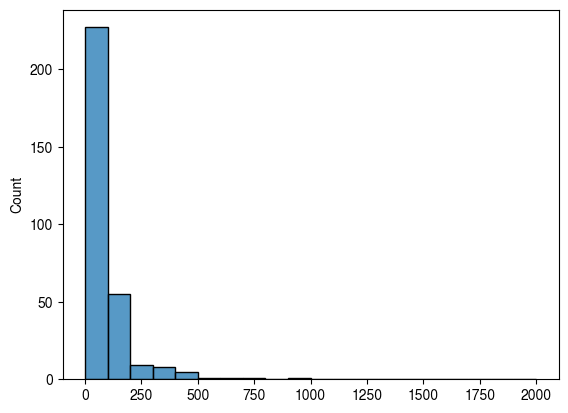

In [105]:
sns.histplot(areas, bins=20, binrange=(0,2000))

In [91]:

base = Path("/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/whole_slice")

for mouse_dir in tqdm(sorted(base.glob("mouse_*")), total=len(sorted(base.glob("mouse_*")))):
    zarr_dir = mouse_dir / "zarr"
    geojson_dir = mouse_dir / "qu_path"

    if not zarr_dir.exists() or not geojson_dir.exists():
        continue

    # Zarrs to process (skip .prev / .jnotebook)
    zarrs = [
        z for z in zarr_dir.glob("*.zarr")
        if not any(s in z.name for s in [".prev", ".jnotebook"])
    ]
    geojsons = list(geojson_dir.glob("*.geojson"))
    if not geojsons:
        continue

    for zarr_fn in zarrs:
        print(f"\n🧩 Processing {zarr_fn.name}")

        # # open zarr
        # root = zarr.open(str(zarr_fn), mode="a")

        # # use level 0/0 as main image
        # arr = da.from_zarr(f"{zarr_fn}/0/0")   # (..., Y, X)
        # shape_yx = arr.shape[-2:]

        # # identity pixel transform (row, col) -> (y, x)
        # transform = Affine.identity()

        # # one merged mask per Zarr
        # merged_mask = np.zeros(shape_yx, dtype="uint8")

        for gj in geojsons:
            print(f"  importing {gj.name}")
            with open(gj) as f:
                gj_data = json.load(f)

            geoms = []
            for feat in gj_data.get("features", []):
                geom = feat.get("geometry")
                if geom:
                    g = shape(geom)
                    # fix invalids/self-intersections
                    try:
                        g = make_valid(g)
                    except Exception:
                        g = g.buffer(0)
                    if not g.is_empty:
                        geoms.append(g)
        print(len(geoms))

  0%|          | 0/11 [00:00<?, ?it/s]


🧩 Processing 20250814_40X_TimerMtb_BP_mice10_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250814_5375.zarr
  importing mouse_1.geojson
18168

🧩 Processing 20250814_40X_TimerMtb_BP_mice10_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250814_5375.zarr
  importing mouse_10.geojson
9819

🧩 Processing 20250901_40X_TimerMtb_BP_mice11_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250902_5555.zarr
  importing mouse_11.geojson
3381

🧩 Processing 20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5551_jnotebook.zarr
  importing mouse_2.geojson
6527

🧩 Processing 20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5551.zarr
  importing mouse_2.geojson
6527

🧩 Processing 20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5552_jnotebook.zarr
  importing mouse_3.geojson
4062

🧩 Processing 20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5552.zarr


In [85]:
geojsons

[PosixPath('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/whole_slice/mouse_1/qu_path/mouse_1.geojson')]

### Rest

In [67]:
from pathlib import Path

import numpy as np
import zarr
from tqdm.auto import tqdm

BASE = Path("/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/whole_slice")

# all image zarrs (skip .prev / .jnotebook)
zarr_roots = sorted(
    p for p in BASE.glob("mouse_*/zarr/*.zarr")
    if ".prev" not in p.name and ".jnotebook" not in p.name
)

for zarr_fn in tqdm(zarr_roots):
    z = zarr.open(str(zarr_fn), mode="a")
    if "masks" not in z:
        continue
    
    masks = z["masks"]
    
    # pick source mask array (prefer one named mouse_*)
    src_name = None
    src_arr = None
    for name in masks.keys():          # <-- .items() → .keys()
        obj = masks[name]              # Group __getitem__ returns Array or Group
        if isinstance(obj, zarr.Array) and (src_name is None or name.startswith("mouse_")):
            src_name = name
            src_arr = obj
    
    if src_arr is None:
        print(f"{zarr_fn.name}: no arrays under /masks, skipping")
        continue
    
    print(f"{zarr_fn.name}: promoting /masks/{src_name} -> /labels/ground_truth_mtb/0")
    
    # ensure plain 2D (Y, X)
    data = np.asarray(src_arr)
    if data.ndim > 2:
        data = data.reshape(data.shape[-2], data.shape[-1])
    
    # ---- create NGFF label group ----
    labels_root = z.require_group("labels")
    lbl_group   = labels_root.require_group("ground_truth_mtb")
    
    # create / overwrite dataset '0'
    if "0" in lbl_group:
        del lbl_group["0"]
    lbl_arr = lbl_group.create_array(
        "0",
        shape=data.shape,
        dtype=data.dtype,
        chunks="auto",
    )
    lbl_arr[...] = data
    
    # copy any attrs from old mask array
    try:
        attrs_dict = src_arr.attrs.asdict()
    except AttributeError:
        attrs_dict = dict(src_arr.attrs)
    lbl_arr.attrs.update(attrs_dict)
    
    # NGFF multiscales metadata for the label
    lbl_group.attrs["multiscales"] = [{
        "name": "ground_truth_mtb",
        "version": "0.4",
        "axes": [
            {"name": "y", "type": "space", "unit": "pixel"},
            {"name": "x", "type": "space", "unit": "pixel"},
        ],
        "datasets": [{"path": "0"}],
    }]
    
    # Point back to the image group (parent of /labels)
    lbl_group.attrs["image-label"] = {
        "version": "0.4",
        "source": ".."
    }
    
    # OPTIONAL: once you're happy, remove old masks
    # del z["masks"]
    
print("✅ Done – each Zarr now has /labels/ground_truth_mtb/0 as an NGFF label.")


  0%|          | 0/14 [00:00<?, ?it/s]

20250814_40X_TimerMtb_BP_mice10_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250814_5375.zarr: promoting /masks/mouse_1 -> /labels/ground_truth_mtb/0
20250901_40X_TimerMtb_BP_mice11_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250902_5555.zarr: promoting /masks/mouse_11 -> /labels/ground_truth_mtb/0
20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5551.zarr: promoting /masks/mouse_2 -> /labels/ground_truth_mtb/0
20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5551_jnotebook.zarr: promoting /masks/mouse_2 -> /labels/ground_truth_mtb/0
20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5552.zarr: promoting /masks/mouse_3 -> /labels/ground_truth_mtb/0
20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5552_jnotebook.zarr: promoting /masks/mouse_3 -> /labels/ground_truth_mtb/0
20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_Timer

### Identify vsi/ets pairs for conversion

In [ ]:
# root = Path("/mnt/NEMO/home/shared/Shared - Baptiste Pradel/Histology")
root = Path("/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/whole_slice/")

# mouse dirs ≥ 7
mouse_dirs = sorted(
    [p for p in root.glob("mouse_*") if int(p.name.removeprefix("mouse_")) >= 7],
    key=lambda p: int(p.name.removeprefix("mouse_")),
)

# largest .ets per mouse
largest_ets_per_mouse = []
for mouse_dir in mouse_dirs:
    ets_files = list(mouse_dir.rglob("*.ets"))
    if ets_files:
        largest_ets_per_mouse.append(max(ets_files, key=lambda f: f.stat().st_size))

# map each .ets to its sibling .vsi using the 2nd parent folder name
def ets_to_vsi(ets_path: Path) -> Path:
    acq_dir = ets_path.parent.parent.name              # e.g. "_20250901_..._5555_"
    acq_base = acq_dir.strip("_")                      # -> "20250901_..._5555"
    mouse_dir = ets_path.parents[2]     # .../<mouse_N>/
    return mouse_dir / f"{acq_base}.vsi"               # .../<mouse_N>/<acq_base>.vsi

corresponding_vsi = []
for ets in largest_ets_per_mouse:
    vsi = ets_to_vsi(ets)
    corresponding_vsi.append(vsi if vsi.exists() else None)

# show pairs (and which are missing)
for ets, vsi in zip(largest_ets_per_mouse, corresponding_vsi):
    print(f"{ets}  ->  {vsi if vsi else 'NO MATCH'}")


## Convert to tiff

This code previous worked in two stages from terminal

~/bftools/bfconvert \
-bigtiff -compression LZW \
-series 0 \
"20250814_40X_TimerMtb_BP_mice10_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250814_5375.vsi" \
"exports/mtb_slice_5375_s0.ome.tif"

bfconvert \ 
mtb_slice_5375_s0.ome.tif \
mtb_slice_5375_pyr.ome.tiff \
-bigtiff \
-pyramid-scale 2 -pyramid-resolutions 5 \
-tilex 512 -tiley 512 \
-compression LZW

I think it was the series that did it

In [ ]:
vsi_fns = [str(i) for i in corresponding_vsi]

In [ ]:
vsi_fns

#### Omitted series 0 from argument, using old version of bftools

In [ ]:
for vsi_fn in tqdm(vsi_fns):
    tif_fn = vsi_fn.replace('vsi', 'tif')
    !~/bftools/bfconvert \
    -bigtiff -compression LZW \
    -tilex 2048 -tiley 2048 \
    "$vsi_fn" \
    "$tif_fn"

## Convert to Zarr

In [ ]:
import dask.array as da
import tifffile
import zarr
from dask.diagnostics import ProgressBar
from ome_zarr.io import parse_url
from ome_zarr.writer import (
    add_metadata,
    write_image,
    write_multiscales_metadata,
)

In [ ]:
tif_fns = glob.glob('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/whole_slice/mouse*/tif/*')

In [ ]:
for tif_fn in tqdm(tif_fns):
    try:
        if 'ome' in tif_fn:
            print('skipping suspect corrupt')
            continue
        else:
            zarr_image = tifffile.imread(tif_fn, aszarr=True)
            dask_image = da.from_zarr(zarr_image)
            print(output_fn, dask_image.shape)
            dask_image = dask_image.transpose(1, 0, 2, 3,)  # lazy; no data copy
            # v0.5 / Zarr v3 store
            out_zarr = tif_fn.replace('.tif', '.zarr')
            store = parse_url(out_zarr, mode="w").store
            root = zarr.group(store=store)
            
            # writes data + builds a 2x YX pyramid by default
            with ProgressBar():  # optional live progress
                write_image(
                    image=dask_image,
                    group=root,
                    axes="czyx",
                    storage_options=dict(chunks=(1, 1, 512, 512)),  # (C,Z,Y,X)
                )
            
            # optional: channel labels for nicer viewing in napari/viv
            add_metadata(root, {"omero": {
                "channels": [
                    {"label": "CF405"},
                    {"label": "CF488"},
                    {"label": "CF561"},
                ]
            }})
        
            # after write_image(... axes="czyx")
            level_names = sorted(root.array_keys(), key=int)   # <-- not group_keys()
            
            axes = [
                {"name": "c", "type": "channel"},
                {"name": "z", "type": "space", "unit": "micrometer"},
                {"name": "y", "type": "space", "unit": "micrometer"},
                {"name": "x", "type": "space", "unit": "micrometer"},
            ]
            
            px_z, px_y, px_x = 2.0, 0.1625, 0.1625
            datasets = []
            for i, p in enumerate(level_names):
                datasets.append({
                    "path": p,
                    "coordinateTransformations": [
                        {"type": "scale", "scale": [1.0, px_z, px_y*(2**i), px_x*(2**i)]},  # C Z Y X
                        {"type": "translation", "translation": [0, 0, 0, 0]},
                    ]
                })
            
            write_multiscales_metadata(root, datasets=datasets, axes=axes)
    except:
        print(tif_fn, 'failed')

### Previous code

In [ ]:
for tif_fn in tqdm(tif_fns):
    zarr_image = tifffile.imread(tif_fn, aszarr=True)
    dask_image = da.from_zarr(zarr_image)
    print(output_fn, dask_image.shape)
    dask_image = dask_image.transpose(1, 0, 2, 3,)  # lazy; no data copy
    # v0.5 / Zarr v3 store
    out_zarr = output_fn.with_suffix('.zarr')

    store = parse_url(out_zarr, mode="w").store
    root = zarr.group(store=store)
    
    # writes data + builds a 2x YX pyramid by default
    with ProgressBar():  # optional live progress
        write_image(
            image=dask_image,
            group=root,
            axes="czyx",
            storage_options=dict(chunks=(1, 1, 512, 512)),  # (C,Z,Y,X)
        )
    
    # optional: channel labels for nicer viewing in napari/viv
    add_metadata(root, {"omero": {
        "channels": [
            {"label": "CF405"},
            {"label": "CF488"},
            {"label": "CF561"},
        ]
    }})

    # after write_image(... axes="czyx")
    level_names = sorted(root.array_keys(), key=int)   # <-- not group_keys()
    
    axes = [
        {"name": "c", "type": "channel"},
        {"name": "z", "type": "space", "unit": "micrometer"},
        {"name": "y", "type": "space", "unit": "micrometer"},
        {"name": "x", "type": "space", "unit": "micrometer"},
    ]
    
    px_z, px_y, px_x = 2.0, 0.1625, 0.1625
    datasets = []
    for i, p in enumerate(level_names):
        datasets.append({
            "path": p,
            "coordinateTransformations": [
                {"type": "scale", "scale": [1.0, px_z, px_y*(2**i), px_x*(2**i)]},  # C Z Y X
                {"type": "translation", "translation": [0, 0, 0, 0]},
            ]
        })
    
    write_multiscales_metadata(root, datasets=datasets, axes=axes)


# Arx

In [ ]:
import time
from datetime import datetime, timedelta
from pathlib import Path

# ---- config ----
ref_path = Path("/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/whole_slice/_20250814_40X_TimerMtb_BP_mice10_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250814_5375_/stack1/frame_t_0.ets")
out_path = Path("/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/whole_slice/exports/mtb_slice_5375_s0.ome.tif")

check_every_s = 90           # polling interval
min_samples_for_eta = 5      # wait this many samples before showing ETA
window_samples = 5           # moving-average window for rate
stall_threshold_gb = 0.01    # consider “no progress” if growth < this per interval
stall_checks = 60             # consecutive stalls before we say “probably done”
target_equals_ref = True     # if False, don’t compare to ref size; just use stall logic
# -----------------

def gb(bytes_): return bytes_ / (1024**3)

ref_size_gb = gb(ref_path.stat().st_size)
print(f"Reference size: {ref_size_gb:.2f} GB (for context)\n")

sizes = []
times = []
no_progress = 0

while True:
    if out_path.exists():
        s = gb(out_path.stat().st_size)
        t = time.time()
        sizes.append(s); times.append(t)

        # progress %
        pct_str = f"{(s/ref_size_gb*100):.1f}%" if ref_size_gb > 0 else "—"

        # compute smoothed rate after we have enough points
        eta_str = "estimating…"
        rate_gb_per_min = 0.0
        if len(sizes) >= min_samples_for_eta:
            w = sizes[-window_samples:]
            wt = times[-window_samples:]
            ds = w[-1] - w[0]
            dt_min = (wt[-1] - wt[0]) / 60
            if dt_min > 0 and ds > 0:
                rate_gb_per_min = ds / dt_min

                if target_equals_ref:
                    rem = max(ref_size_gb - s, 0.0)
                    if rate_gb_per_min > 0:
                        minutes = rem / rate_gb_per_min
                        eta_time = datetime.now() + timedelta(minutes=minutes)
                        eta_str = eta_time.strftime("%H:%M:%S")
                else:
                    eta_str = "—"  # unknown final size; stall detection will stop loop

        # detect stalls (don’t trigger on first sample)
        if len(sizes) >= 2:
            delta = sizes[-1] - sizes[-2]
            if delta < stall_threshold_gb:
                no_progress += 1
            else:
                no_progress = 0

        # status line
        print(
            f"\r{datetime.now().strftime('%H:%M:%S')} | "
            f"{s:7.2f} GB ({pct_str}) | "
            f"{rate_gb_per_min:5.2f} GB/min | ETA {eta_str} | "
            f"stalls {no_progress}/{stall_checks}",
            end=""
        )

        # stop conditions:
        done_by_size = target_equals_ref and (s >= 0.995 * ref_size_gb)
        done_by_stall = no_progress >= stall_checks
        if done_by_size or done_by_stall:
            print("\n✅ Done (size target reached or growth stalled).")
            break
    else:
        print("\rWaiting for output file...", end="")

    time.sleep(check_every_s)
    